# Q2 – Human Parsing and Agnostic Representation

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!nvidia-smi

import torch

print("Torch :", torch.__version__)
print("CUDA  :", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

Sun Jul 26 17:10:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Environment Setup

In [ ]:
!pip -q install transformers accelerate timm sentencepiece
!pip -q install opencv-python pillow matplotlib tqdm
!pip -q install rembg onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 11.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.66.0 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.66.0 which is incompatible.
py

## 2. Dataset Preparation

In [ ]:
!mkdir -p /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset

!unzip -q \
"/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/V5.zip" \
-d "/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset"

unzip:  cannot find or open /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/V5.zip, /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/V5.zip.zip or /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/V5.zip.ZIP.


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Reels ', 'doc clgf', 'mits', 'Classroom', 'NANDANA R RESUME (1).pdf', 'DOC-20250709-WA0007. (5).pdf', 'Nandana_R_Resume (6).pdf', 'Nandana R_Resume_MITS_CSEAI_SmartHMS_Hiring.pdf', 'Nandana R_Resume_MITS_CSEAI_SmartHMS_Hiring (1).pdf', 'Nandana R_Resume_MITS_CSEAI_SmartHMS_Hiring (2).pdf', 'Nandana R_Resume_MITS_TNP_DS_Intern26 (1).pdf', 'Saved from the Google app', 'Nandana_R_Resume (2) (2).pdf', 'Nandana R_Resume_PythonAIDev_ProjectFashionX.pdf', 'Nandana R_Resume (7).pdf', 'Nandana R_Resume_MITS_Claysys_PM.pdf', 'Nandana R_Resume (6).pdf', 'Nandana_R_Resume (2) (1).pdf', 'Nandana R Resume', 'IPmodule3 (3).pdf', 'IPmodule3 (2).pdf', 'video-output-3AA806F4-D810-4C44-A6BD-D1C80FD671D2-1.mov', 'Nandana R ', 'Nandana R_Resume (5).pdf', 'Nandana R_Reizend_CSAI\n.pdf', 'Nandana R_Resume (4).pdf', 'Nandana_R_Resume (5) (1).pdf', "Nandana R_Resume_MITS'26_AI.pdf", 'Nandana R_Resume (3).pdf', 'IPmodule3 (1).pdf', 'IPmodule3.pdf', 'AI-Driven Health Insurance Claim Verifier

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/XIPL_SDE_Assessment"):
    print(root)

/content/drive/MyDrive/XIPL_SDE_Assessment
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/test_pairs
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/test_pairs/person
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/test_pairs/garment
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/edge_cases
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/parsing_maps
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/agnostic
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/garment_masks
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/edge_cases
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/edge_cases/parsing_maps
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/edge_cases/agnostic
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/clothing_masks
/content/drive/MyDrive/XIPL_SDE_Ass

In [ ]:
import os

DATASET = "/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset"

for root, dirs, files in os.walk(DATASET):
    print(root)

/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/test_pairs
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/test_pairs/person
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/test_pairs/garment
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/edge_cases


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/XIPL_SDE_Assessment"))

['Q2', 'Q3', 'Q4', 'Q1', 'Q5', 'Q5_(2).ipynb']


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/XIPL_SDE_Assessment"))

['Q2', 'Q3', 'Q4', 'Q1', 'Q5', 'Q5_(2).ipynb']


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/XIPL_SDE_Assessment/V5.zip"
extract_to = "/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_to)

print("✅ Dataset extracted successfully")

✅ Dataset extracted successfully


In [ ]:
!find /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset -maxdepth 3

/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/evaluation_template_q4.csv
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/sample_output_q1.json
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/SUBMISSION_TEMPLATE.md
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/test_pairs
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/test_pairs/person
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/test_pairs/garment
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/test_pairs/pairs_manifest.csv
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/edge_cases
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/edge_cases/person_side_pose.jpg
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/edge_cases/edge_

In [ ]:
import os

ROOT = "/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files"

PERSON_PATH = os.path.join(ROOT, "test_pairs", "person")
GARMENT_PATH = os.path.join(ROOT, "test_pairs", "garment")
EDGE_PATH = os.path.join(ROOT, "edge_cases")

OUTPUT_ROOT = "/content/drive/MyDrive/XIPL_SDE_Assessment/Q2"

PARSING_PATH = os.path.join(OUTPUT_ROOT, "parsing_maps")
AGNOSTIC_PATH = os.path.join(OUTPUT_ROOT, "agnostic")
GARMENT_MASK_PATH = os.path.join(OUTPUT_ROOT, "garment_masks")
CLOTHING_MASK_PATH = os.path.join(OUTPUT_ROOT, "clothing_masks")

os.makedirs(PARSING_PATH, exist_ok=True)
os.makedirs(AGNOSTIC_PATH, exist_ok=True)
os.makedirs(GARMENT_MASK_PATH, exist_ok=True)
os.makedirs(CLOTHING_MASK_PATH, exist_ok=True)

print("Persons :", os.listdir(PERSON_PATH))
print("Garments:", os.listdir(GARMENT_PATH))
print("Edges   :", os.listdir(EDGE_PATH))

Persons : ['person_01.png', 'person_05.png', 'person_02.png', 'person_03.png', 'person_04.png']
Garments: ['garment_05.jpg', 'garment_01.jpg', 'garment_03.jpg', 'garment_04.jpg', 'garment_02.jpg']
Edges   : ['person_side_pose.jpg', 'edge_cases_manifest.csv', 'no_person.jpg', 'person_crossed_arms.jpg', 'person_seated.jpg']


In [ ]:
!pip uninstall -y Pillow
!pip install --no-cache-dir --force-reinstall Pillow==10.4.0

Found existing installation: pillow 10.4.0
Uninstalling pillow-10.4.0:
  Successfully uninstalled pillow-10.4.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 77.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rembg 2.0.77 requires pillow<13.0.0,>=12.1.0, but you have pillow 10.4.0 which is incompatible.
cucim-cu12 26.2.0 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.


In [ ]:
import PIL
from PIL import Image, ImageFont

print("Pillow version:", PIL.__version__)

# Simple verification
img = Image.new("RGB", (100, 100), "white")

print("Image module:", Image)
print("ImageFont module:", ImageFont)
print("✅ Pillow working correctly")

Pillow version: 10.4.0
Image module: <module 'PIL.Image' from '/usr/local/lib/python3.12/dist-packages/PIL/Image.py'>
ImageFont module: <module 'PIL.ImageFont' from '/usr/local/lib/python3.12/dist-packages/PIL/ImageFont.py'>
✅ Pillow working correctly


In [ ]:
import torch
import transformers

from transformers import (
    AutoImageProcessor,
    AutoModelForSemanticSegmentation
)

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("✅ Q2 imports working")

Torch: 2.11.0+cu128
Transformers: 5.13.1
CUDA available: True
GPU: Tesla T4
✅ Q2 imports working


## 3. Load SCHP Model

In [ ]:
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(
    "pirocheto/schp-atr-18",
    trust_remote_code=True
)

model = AutoModelForSemanticSegmentation.from_pretrained(
    "pirocheto/schp-atr-18",
    trust_remote_code=True
)

model.to(DEVICE)
model.eval()

print("✅ SCHP Loaded Successfully")
print("Device:", DEVICE)

preprocessor_config.json:   0%|          | 0.00/302 [00:00<?, ?B/s]

image_processing_schp.py:   0%|          | 0.00/3.37k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/pirocheto/schp-atr-18:
- image_processing_schp.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

configuration_schp.py:   0%|          | 0.00/1.48k [00:00<?, ?B/s]

...

[transformers] A new version of the following files was downloaded from https://huggingface.co/pirocheto/schp-atr-18:
- modeling_schp.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors: reconstructing file:   0%|          |  0.00B /  267MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/722 [00:00<?, ?it/s]

✅ SCHP Loaded Successfully
Device: cuda


## 4. Generate Parsing Maps

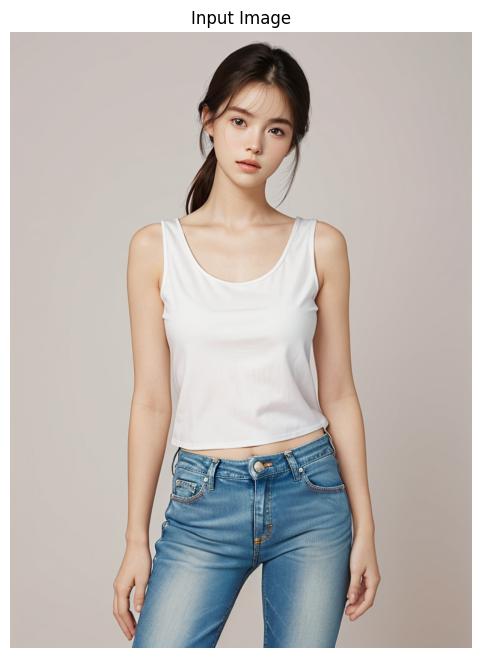

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

image_path = os.path.join(PERSON_PATH, "person_01.png")

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,8))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [ ]:
inputs = processor(
    images=image,
    return_tensors="pt"
).to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs)

print(type(outputs))

<class 'transformers_modules.pirocheto.schp_hyphen_atr_hyphen_18.61f4ff3c508b899904e495cefbbaff9cacadeb45.modeling_schp.SCHPSemanticSegmenterOutput'>


In [ ]:
import numpy as np

parsing_map = outputs.parsing_logits.argmax(dim=1)[0].cpu().numpy()

print("Shape:", parsing_map.shape)
print("Classes:", np.unique(parsing_map))

Shape: (512, 512)
Classes: [ 0  2  4  6  8 11 14 15]


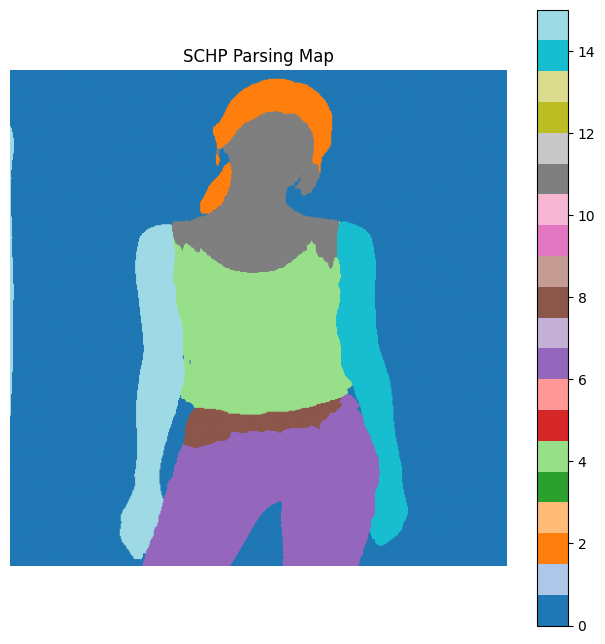

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(parsing_map, cmap="tab20")
plt.colorbar()
plt.title("SCHP Parsing Map")
plt.axis("off")
plt.show()

In [ ]:
import cv2

cv2.imwrite(
    os.path.join(PARSING_PATH, "person_01.png"),
    parsing_map.astype(np.uint8)
)

print("✅ Parsing map saved.")

✅ Parsing map saved.


In [ ]:
import torch
import numpy as np

# Get class probabilities
prob = torch.softmax(outputs.parsing_logits[0], dim=0).cpu().numpy()

upper_prob = prob[4]     # Upper clothes
dress_prob = prob[7]     # Dress
belt_prob = prob[8]      # Belt

cloth_mask = (
    (upper_prob > 0.20) |
    (dress_prob > 0.20) |
    (belt_prob > 0.20)
).astype(np.uint8)

print("Mask created.")

Mask created.


In [ ]:
import cv2

h, w = cloth_mask.shape

# Only refine the upper torso region
shoulder_region = np.zeros_like(cloth_mask)

shoulder_region[
    int(h*0.08):int(h*0.40),
    :
] = 1

kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (5,5)
)

expanded = cv2.dilate(
    cloth_mask,
    kernel,
    iterations=1
)

cloth_mask = np.where(
    shoulder_region == 1,
    expanded,
    cloth_mask
)

In [ ]:
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (3,3)
)

cloth_mask = cv2.morphologyEx(
    cloth_mask,
    cv2.MORPH_CLOSE,
    kernel
)

In [ ]:
cloth_mask = cv2.resize(
    cloth_mask,
    (image.width, image.height),
    interpolation=cv2.INTER_NEAREST
)

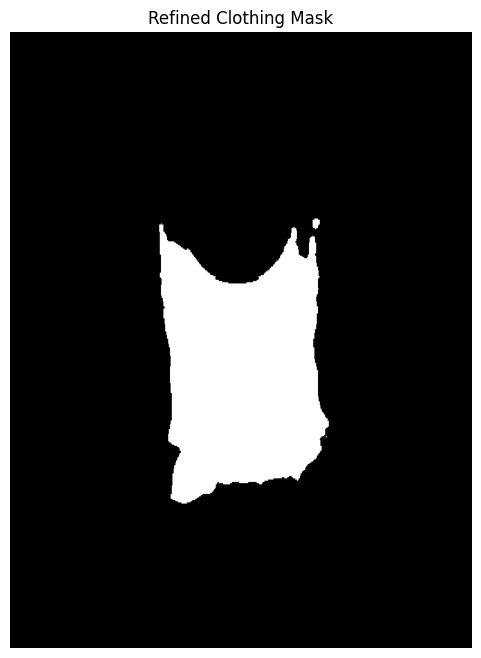

In [ ]:
plt.figure(figsize=(6,8))

plt.imshow(
    cloth_mask,
    cmap="gray"
)

plt.title("Refined Clothing Mask")
plt.axis("off")
plt.show()

## 5. Create Agnostic Images

In [ ]:
import numpy as np

# Convert PIL image to NumPy array
image_np = np.array(image)

# Copy original image
agnostic = image_np.copy()

# Replace clothing pixels with gray
agnostic[cloth_mask == 1] = [128, 128, 128]

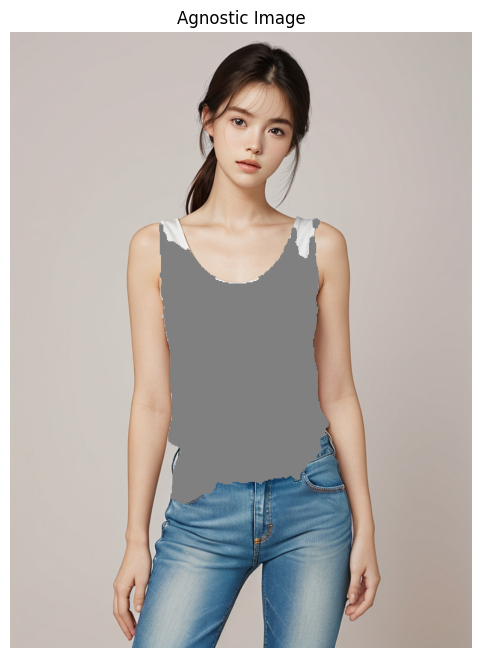

In [ ]:
plt.figure(figsize=(6,8))
plt.imshow(agnostic)
plt.title("Agnostic Image")
plt.axis("off")
plt.show()

In [ ]:
from PIL import Image
import os

save_path = os.path.join(
    AGNOSTIC_PATH,
    "person_01.png"
)

Image.fromarray(agnostic).save(save_path)

print("✅ Agnostic image saved to:", save_path)

✅ Agnostic image saved to: /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/agnostic/person_01.png


In [ ]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm

person_files = sorted([
    f for f in os.listdir(PERSON_PATH)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

print("Found", len(person_files), "person images")

Found 5 person images


In [ ]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm

for file_name in tqdm(person_files):

    image_path = os.path.join(PERSON_PATH, file_name)

    image = Image.open(image_path).convert("RGB")

    # ---------------------------
    # SCHP Inference
    # ---------------------------
    inputs = processor(
        images=image,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    # ---------------------------
    # Parsing Map
    # ---------------------------
    parsing_map = outputs.parsing_logits.argmax(dim=1)[0].cpu().numpy()

    cv2.imwrite(
        os.path.join(PARSING_PATH, file_name),
        parsing_map.astype(np.uint8)
    )

    # ---------------------------
    # Confidence Mask
    # ---------------------------
    prob = torch.softmax(
        outputs.parsing_logits[0],
        dim=0
    ).cpu().numpy()

    upper = prob[4]
    dress = prob[7]
    belt = prob[8]

    cloth_mask = (
        (upper > 0.20) |
        (dress > 0.20) |
        (belt > 0.20)
    ).astype(np.uint8)

    # ---------------------------
    # Morphology
    # ---------------------------
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5,5)
    )

    cloth_mask = cv2.morphologyEx(
        cloth_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    cloth_mask = cv2.resize(
        cloth_mask,
        (image.width, image.height),
        interpolation=cv2.INTER_NEAREST
    )

    # ---------------------------
    # Save Binary Clothing Mask
    # ---------------------------
    Image.fromarray(
        (cloth_mask * 255).astype(np.uint8)
    ).save(
        os.path.join(
            CLOTHING_MASK_PATH,
            file_name
        )
    )

    # ---------------------------
    # Agnostic Image
    # ---------------------------
    image_np = np.array(image)

    agnostic = image_np.copy()

    agnostic[cloth_mask == 1] = [128, 128, 128]

    Image.fromarray(
        agnostic
    ).save(
        os.path.join(
            AGNOSTIC_PATH,
            file_name
        )
    )

print("✅ Batch processing completed.")

100%|██████████| 5/5 [00:06<00:00,  1.32s/it]

✅ Batch processing completed.


In [ ]:
import os

print(os.listdir(CLOTHING_MASK_PATH))

['person_01.png', 'person_03.png', 'person_02.png', 'person_04.png', 'person_05.png']


L


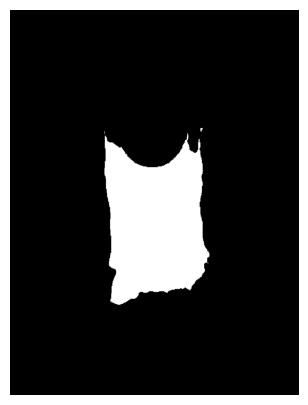

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

mask = Image.open(
    "/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/clothing_masks/person_01.png"
)

print(mask.mode)

plt.figure(figsize=(5,5))
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
print("Parsing Maps:")
print(sorted(os.listdir(PARSING_PATH)))

print("\nAgnostic Images:")
print(sorted(os.listdir(AGNOSTIC_PATH)))

Parsing Maps:
['person_01.png', 'person_02.png', 'person_03.png', 'person_04.png', 'person_05.png']

Agnostic Images:
['person_01.png', 'person_02.png', 'person_03.png', 'person_04.png', 'person_05.png']


## 6. Handle Edge Cases

In [ ]:
import os

edge_files = sorted([
    f for f in os.listdir(EDGE_PATH)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

print(edge_files)

['no_person.jpg', 'person_crossed_arms.jpg', 'person_seated.jpg', 'person_side_pose.jpg']


In [ ]:
import os

edge_files = sorted([
    f for f in os.listdir(EDGE_PATH)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Edge Files:")
print(edge_files)

Edge Files:
['no_person.jpg', 'person_crossed_arms.jpg', 'person_seated.jpg', 'person_side_pose.jpg']


In [ ]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm

EDGE_OUTPUT = os.path.join(OUTPUT_ROOT, "edge_cases")

EDGE_PARSING = os.path.join(EDGE_OUTPUT, "parsing_maps")
EDGE_AGNOSTIC = os.path.join(EDGE_OUTPUT, "agnostic")

os.makedirs(EDGE_PARSING, exist_ok=True)
os.makedirs(EDGE_AGNOSTIC, exist_ok=True)

for file_name in tqdm(edge_files):

    # Skip non-image files
    if not file_name.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    image_path = os.path.join(EDGE_PATH, file_name)

    image = Image.open(image_path).convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    parsing_map = outputs.parsing_logits.argmax(dim=1)[0].cpu().numpy()

    unique_classes = np.unique(parsing_map)

    # If only background is predicted, treat it as "no person"
    if len(unique_classes) <= 1:
        print(f"Skipping {file_name} (No person detected)")
        continue

    # Save parsing map
    cv2.imwrite(
        os.path.join(EDGE_PARSING, file_name),
        parsing_map.astype(np.uint8)
    )

    # -----------------------
    # Clothing Mask
    # -----------------------

    prob = torch.softmax(outputs.parsing_logits[0], dim=0).cpu().numpy()

    cloth_mask = (
        (prob[4] > 0.20) |
        (prob[7] > 0.20) |
        (prob[8] > 0.20)
    ).astype(np.uint8)

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5,5)
    )

    cloth_mask = cv2.morphologyEx(
        cloth_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    cloth_mask = cv2.resize(
        cloth_mask,
        (image.width, image.height),
        interpolation=cv2.INTER_NEAREST
    )

    image_np = np.array(image)

    agnostic = image_np.copy()

    agnostic[cloth_mask == 1] = [128,128,128]

    Image.fromarray(agnostic).save(
        os.path.join(
            EDGE_AGNOSTIC,
            file_name
        )
    )

    print(f"Processed {file_name}")

print("\n✅ Edge case processing completed.")

 25%|██▌       | 1/4 [00:00<00:02,  1.06it/s]

Processed no_person.jpg


 50%|█████     | 2/4 [00:02<00:02,  1.06s/it]

Processed person_crossed_arms.jpg


 75%|███████▌  | 3/4 [00:03<00:01,  1.14s/it]

Processed person_seated.jpg


100%|██████████| 4/4 [00:04<00:00,  1.13s/it]

Processed person_side_pose.jpg

✅ Edge case processing completed.


In [ ]:
print("Parsing Maps:")
print(sorted(os.listdir(EDGE_PARSING)))

print("\nAgnostic Images:")
print(sorted(os.listdir(EDGE_AGNOSTIC)))

Parsing Maps:
['no_person.jpg', 'person_crossed_arms.jpg', 'person_seated.jpg', 'person_side_pose.jpg']

Agnostic Images:
['no_person.jpg', 'person_crossed_arms.jpg', 'person_seated.jpg', 'person_side_pose.jpg']


## 7. Garment Segmentation using rembg

In [ ]:
!pip -q install rembg onnxruntime

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cucim-cu12 26.2.0 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

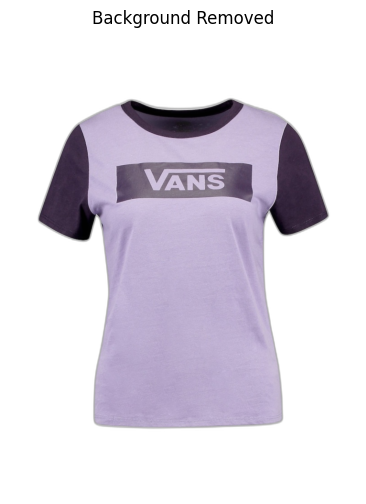

In [ ]:
from rembg import remove
from PIL import Image
import matplotlib.pyplot as plt
import os

garment_path = os.path.join(
    GARMENT_PATH,
    "garment_01.jpg"
)

garment = Image.open(garment_path).convert("RGBA")

result = remove(garment)

plt.figure(figsize=(6,6))
plt.imshow(result)
plt.axis("off")
plt.title("Background Removed")
plt.show()

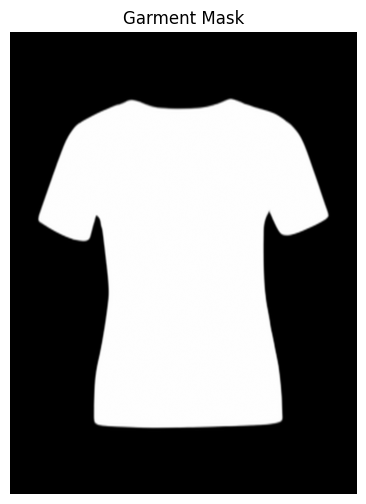

In [ ]:
import numpy as np

rgba = np.array(result)

mask = rgba[:,:,3]

plt.figure(figsize=(6,6))
plt.imshow(mask,cmap="gray")
plt.axis("off")
plt.title("Garment Mask")
plt.show()

In [ ]:
import cv2

save_path = os.path.join(
    GARMENT_MASK_PATH,
    "garment_01.png"
)

cv2.imwrite(save_path,mask)

print("Saved:",save_path)

Saved: /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/garment_masks/garment_01.png


## 8. Verify Outputs

In [ ]:
from rembg import remove
from PIL import Image
import numpy as np
import cv2
import os
from tqdm import tqdm

garment_files = sorted([
    f for f in os.listdir(GARMENT_PATH)
    if f.lower().endswith((".jpg",".jpeg",".png"))
])

print(garment_files)

for file in tqdm(garment_files):

    img = Image.open(
        os.path.join(GARMENT_PATH,file)
    ).convert("RGBA")

    result = remove(img)

    rgba = np.array(result)

    mask = rgba[:,:,3]

    out_name = os.path.splitext(file)[0]+".png"

    cv2.imwrite(
        os.path.join(
            GARMENT_MASK_PATH,
            out_name
        ),
        mask
    )

print("\n✅ All garment masks generated.")

['garment_01.jpg', 'garment_02.jpg', 'garment_03.jpg', 'garment_04.jpg', 'garment_05.jpg']


100%|██████████| 5/5 [00:12<00:00,  2.50s/it]


✅ All garment masks generated.


In [ ]:
print("Parsing Maps :",len(os.listdir(PARSING_PATH)))
print("Agnostic Images :",len(os.listdir(AGNOSTIC_PATH)))
print("Garment Masks :",len(os.listdir(GARMENT_MASK_PATH)))

print("\nGarment Masks")

print(sorted(os.listdir(GARMENT_MASK_PATH)))

Parsing Maps : 5
Agnostic Images : 5
Garment Masks : 5

Garment Masks
['garment_01.png', 'garment_02.png', 'garment_03.png', 'garment_04.png', 'garment_05.png']


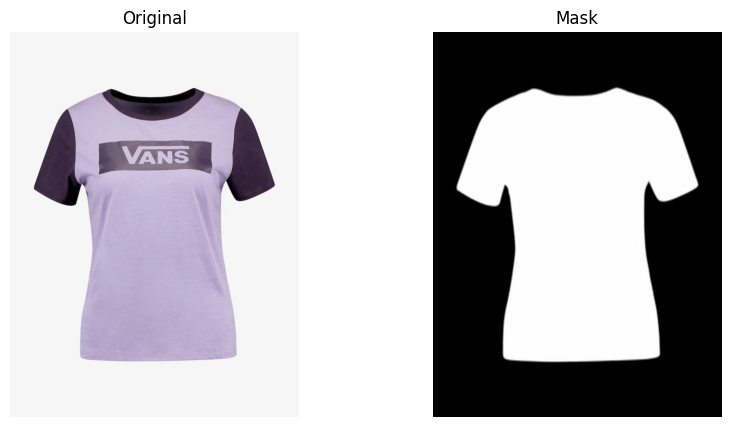

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,2,figsize=(10,5))

ax[0].imshow(
    Image.open(
        os.path.join(GARMENT_PATH,"garment_01.jpg")
    )
)

ax[0].set_title("Original")

ax[0].axis("off")

ax[1].imshow(
    Image.open(
        os.path.join(GARMENT_MASK_PATH,"garment_01.png")
    ),
    cmap="gray"
)

ax[1].set_title("Mask")

ax[1].axis("off")

plt.show()

In [2]:
readme = """# Q2 - Human Parsing & Garment Segmentation Pipeline

## Objective

This task prepares person and garment images for a diffusion-based virtual try-on pipeline.

The pipeline performs three main operations:

1. Generate a human parsing map from the person image.
2. Create an agnostic person representation by masking the upper-body clothing region.
3. Segment the garment from its product image and generate a clean garment mask.

---

## Models Used

### Human Parsing - SCHP

Model:
`pirocheto/schp-atr-18`

SCHP is used to generate semantic human parsing information such as clothing and body regions.

The parsing output is then used to identify the upper-body clothing region required for creating the agnostic representation.

### Garment Segmentation - rembg

`rembg` is used to remove the background from garment product images.

The alpha channel of the resulting image is used to create a binary garment mask.

---

## Model Selection and Comparison

| Model | Advantages | Limitations | Decision |
|------|------------|-------------|----------|
| SCHP | Designed specifically for human parsing and provides semantic body/clothing regions | Parsing can be challenging with occlusion and unusual poses | Selected |
| SAM + Grounding DINO | Powerful general-purpose segmentation and text-guided object detection | Requires multiple models and a more complex, computationally expensive pipeline | Not selected |
| DensePose | Provides detailed body-surface and pose information | Does not directly provide the clothing segmentation needed for this task | Not selected |

SCHP was selected because the task specifically requires human parsing and upper-body clothing identification. It provides the semantic information needed to construct the clothing mask while remaining practical to run in Google Colab.

---

## Person Processing Pipeline

The person preprocessing workflow is:

Person Image
    |
    v
SCHP Human Parsing
    |
    v
Parsing Map
    |
    v
Upper-Body Clothing Mask
    |
    v
Mask Refinement
    |
    v
Agnostic Person Representation

The clothing mask is generated from the SCHP probability output for the relevant clothing classes.

A fixed confidence threshold and morphological refinement are applied to obtain a more consistent mask.

The detected upper-body clothing pixels are replaced with a neutral gray region to create the agnostic representation.

---

## Garment Processing Pipeline

The garment preprocessing workflow is:

Garment Product Image
    |
    v
rembg Background Removal
    |
    v
RGBA Garment Image
    |
    v
Extract Alpha Channel
    |
    v
Binary Garment Mask

This separates the garment from the product-image background while retaining its shape.

---

## Edge Case Handling and Testing

The supplied edge cases were explicitly tested through the same processing pipeline.

### Hair Over Shoulders

`person_02` and `person_03` contain hair overlapping the shoulder/clothing region.

These images were processed using the same SCHP human parsing pipeline to evaluate whether clothing regions can still be separated when hair overlaps the upper body.

### Strappy Sleeveless Garment

`garment_03` contains a strappy sleeveless garment.

The garment is processed using rembg so that the garment silhouette, including thin strap regions, can be retained in the garment mask.

### Crossed Arms

`edge_cases/person_crossed_arms.jpg` tests human parsing when the arms overlap the upper-body clothing.

The image is processed using SCHP and both the required parsing map and agnostic representation are generated.

### Side Pose

The supplied side-pose image was additionally passed through the SCHP pipeline to test parsing and clothing-mask robustness under a non-front-facing body orientation.

### Seated Pose

The supplied seated-person image was additionally tested to observe the behavior of the parsing and agnostic-generation pipeline on a seated posture.

### No-Person Image

The supplied no-person image was also tested diagnostically.

SCHP is a human parsing model rather than a dedicated person detector. Therefore, no-person rejection should not rely only on SCHP output. In the complete web-demo pipeline, person validation is handled as a guardrail before try-on processing.

---

## No Filename-Specific Hardcoding

The edge-case outputs are not manually created or hardcoded for individual filenames.

The supplied images are passed through the same SCHP/rembg processing pipeline used for the normal inputs.

The implementation uses fixed processing hyperparameters such as:

- SCHP semantic clothing classes
- Confidence thresholds
- Morphological operations

These are general pipeline parameters and are not manually changed based on a particular test-image filename.

---

## Outputs

The pipeline generates:

### Person Outputs

- Human parsing maps
- Upper-body clothing masks
- Agnostic person representations

### Garment Outputs

- Background-removed garment images
- Binary garment masks

### Edge-Case Outputs

The crossed-arms case includes the required:

- Parsing map
- Agnostic person representation

Additional supplied edge cases were also tested for robustness.

---

## Folder Structure

Q2/
├── person/
├── garment/
├── edge_cases/
├── parsing_maps/
├── agnostic/
├── garment_masks/
├── Q2.ipynb
└── README.md

---

## Libraries Used

- PyTorch
- Transformers
- OpenCV
- NumPy
- Pillow
- rembg
- ONNX Runtime

---

## Implementation Notes

- SCHP performs semantic human parsing.
- Clothing masks are derived from SCHP probability outputs.
- Morphological processing is used to refine clothing-mask regions.
- Agnostic images replace the detected upper-body clothing region with a neutral gray region.
- rembg performs garment background removal.
- Garment masks are extracted from the resulting alpha channel.
- Edge cases are processed through the same general pipeline rather than using manually generated masks.

---

## Author

Nandana R
"""

with open(
    "/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/README.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)

print("✅ Final Q2 README updated successfully!")
print("/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/README.md")

✅ Final Q2 README updated successfully!
/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/README.md


In [ ]:
import os

MASK_OUTPUT_DIR = "/content/drive/MyDrive/XIPL_SDE_Assessment/Q2/clothing_masks"

os.makedirs(MASK_OUTPUT_DIR, exist_ok=True)

print("✅ Folder created:", MASK_OUTPUT_DIR)

✅ Folder created: /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/clothing_masks


Testing: /content/drive/MyDrive/XIPL_SDE_Assessment/Q2/dataset/sample_files/edge_cases/no_person.jpg
Exists: True


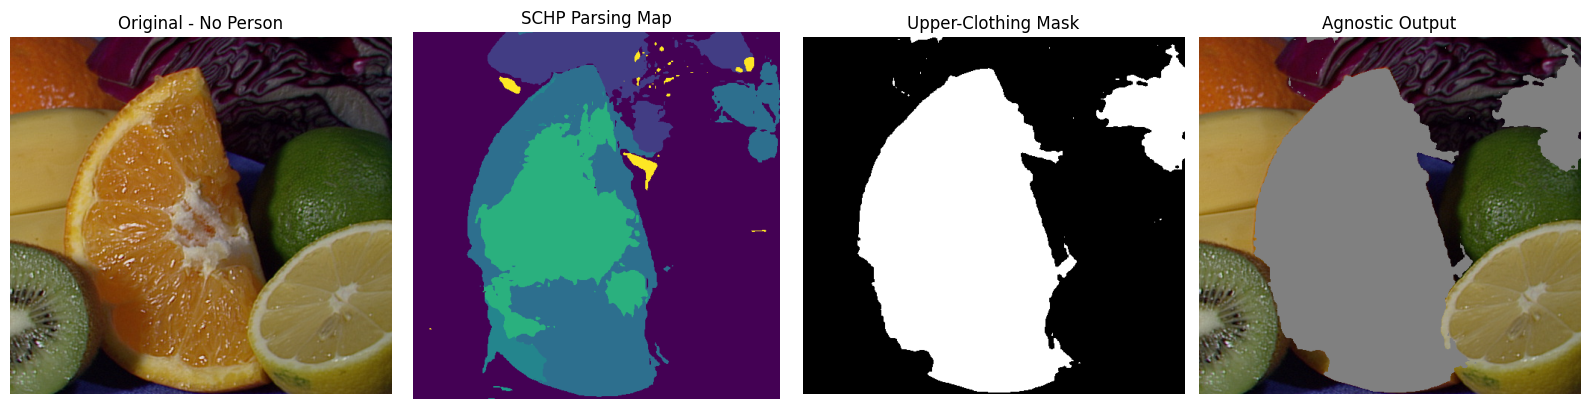


===== NO-PERSON DIAGNOSTIC =====
Unique parsing labels: [ 0  2  4  5  6  7 11]
Masked pixels: 96385
Mask percentage: 39.22 %


In [ ]:
import os
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# ---------------------------------------------------------
# NO-PERSON Q2 DIAGNOSTIC TEST
# ---------------------------------------------------------

no_person_path = os.path.join(
    EDGE_PATH,
    "no_person.jpg"
)

print("Testing:", no_person_path)
print("Exists:", os.path.exists(no_person_path))

# 1. Load image
image = Image.open(no_person_path).convert("RGB")

# 2. Run the SAME SCHP parsing pipeline
inputs = processor(
    images=image,
    return_tensors="pt"
).to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs)

# Parsing prediction
parsing_map = (
    outputs.parsing_logits
    .argmax(dim=1)[0]
    .cpu()
    .numpy()
)

# Probabilities
prob = torch.softmax(
    outputs.parsing_logits,
    dim=1
)[0].cpu().numpy()

# 3. SAME clothing-mask logic used in Q2
cloth_mask = (
    (prob[4] > 0.20) |
    (prob[7] > 0.20) |
    (prob[8] > 0.20)
).astype(np.uint8)

# Same morphology
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (5, 5)
)

cloth_mask = cv2.morphologyEx(
    cloth_mask,
    cv2.MORPH_CLOSE,
    kernel
)

# Resize mask if necessary
image_np = np.array(image)

if cloth_mask.shape != image_np.shape[:2]:
    cloth_mask = cv2.resize(
        cloth_mask,
        (image_np.shape[1], image_np.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

# 4. Create agnostic representation
agnostic = image_np.copy()

agnostic[cloth_mask == 1] = [
    128,
    128,
    128
]

# ---------------------------------------------------------
# DISPLAY
# ---------------------------------------------------------

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(image)
plt.title("Original - No Person")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(parsing_map)
plt.title("SCHP Parsing Map")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(cloth_mask, cmap="gray")
plt.title("Upper-Clothing Mask")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(agnostic)
plt.title("Agnostic Output")
plt.axis("off")

plt.tight_layout()
plt.show()

print("\n===== NO-PERSON DIAGNOSTIC =====")
print("Unique parsing labels:", np.unique(parsing_map))
print("Masked pixels:", int(cloth_mask.sum()))
print(
    "Mask percentage:",
    round(
        100 * cloth_mask.sum() / cloth_mask.size,
        2
    ),
    "%"
)

===== Q2 PERSON EDGE-CASE TEST =====

IMAGE: person_02.png
EDGE CASE: Hair over shoulders
EXISTS: True


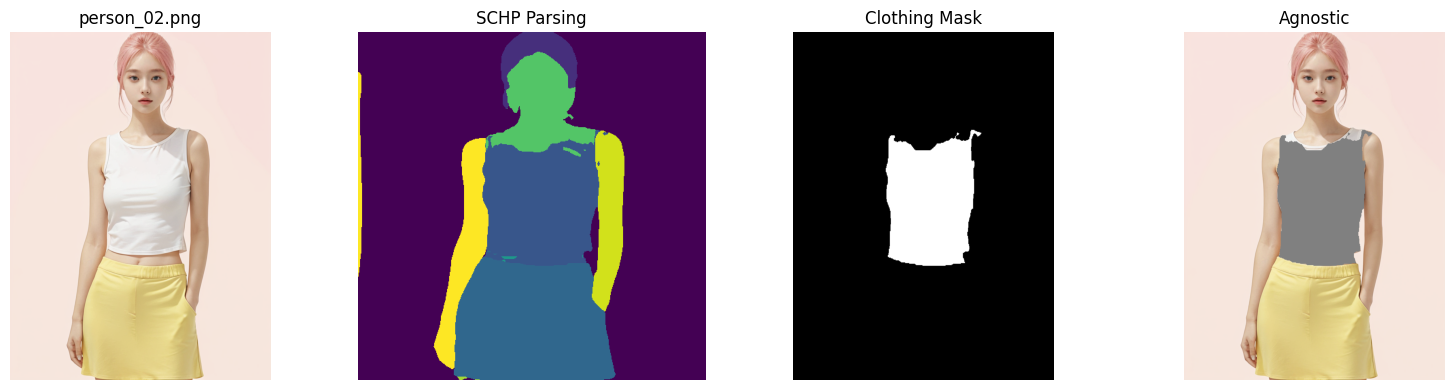

Parsing labels: [ 0  2  4  5  8 11 13 14 15]
Mask percentage: 10.98 %

IMAGE: person_03.png
EDGE CASE: Hair over shoulders
EXISTS: True


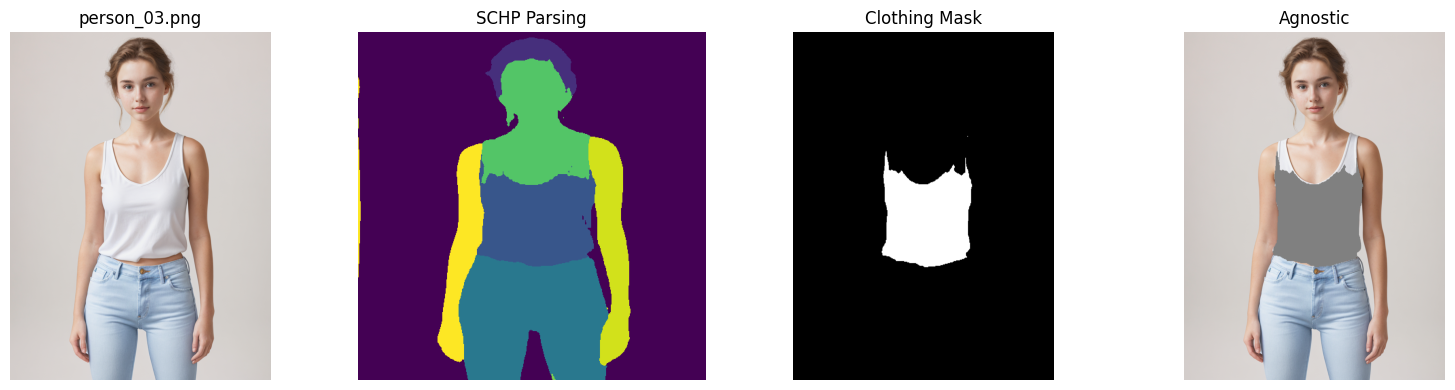

Parsing labels: [ 0  2  4  6 11 12 14 15]
Mask percentage: 8.09 %

IMAGE: person_crossed_arms.jpg
EDGE CASE: Crossed arms
EXISTS: True


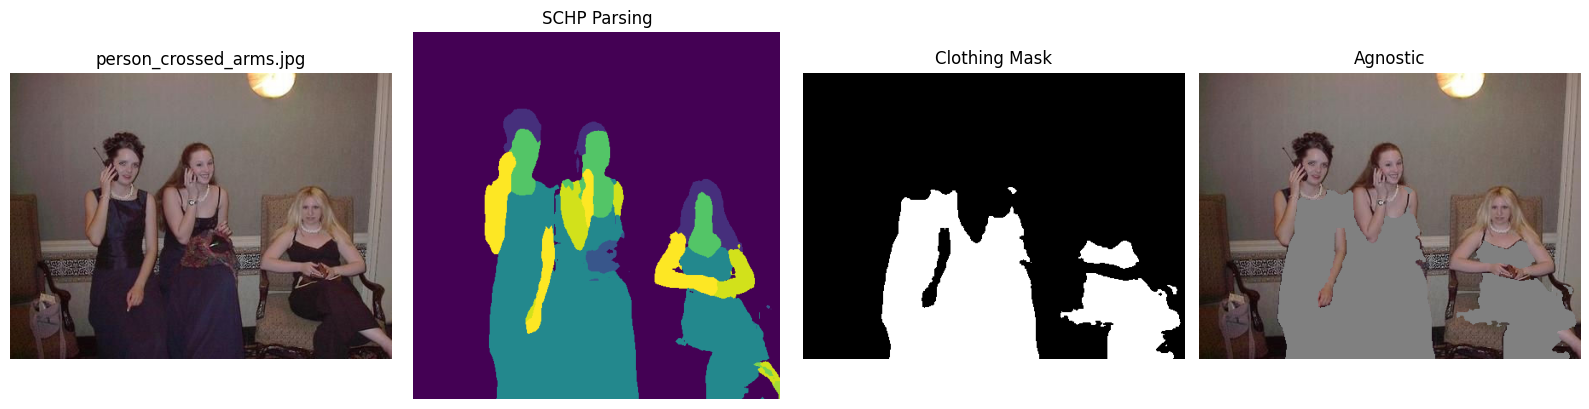

Parsing labels: [ 0  2  4  7 11 12 13 14 15]
Mask percentage: 24.83 %

IMAGE: no_person.jpg
EDGE CASE: No person
EXISTS: True


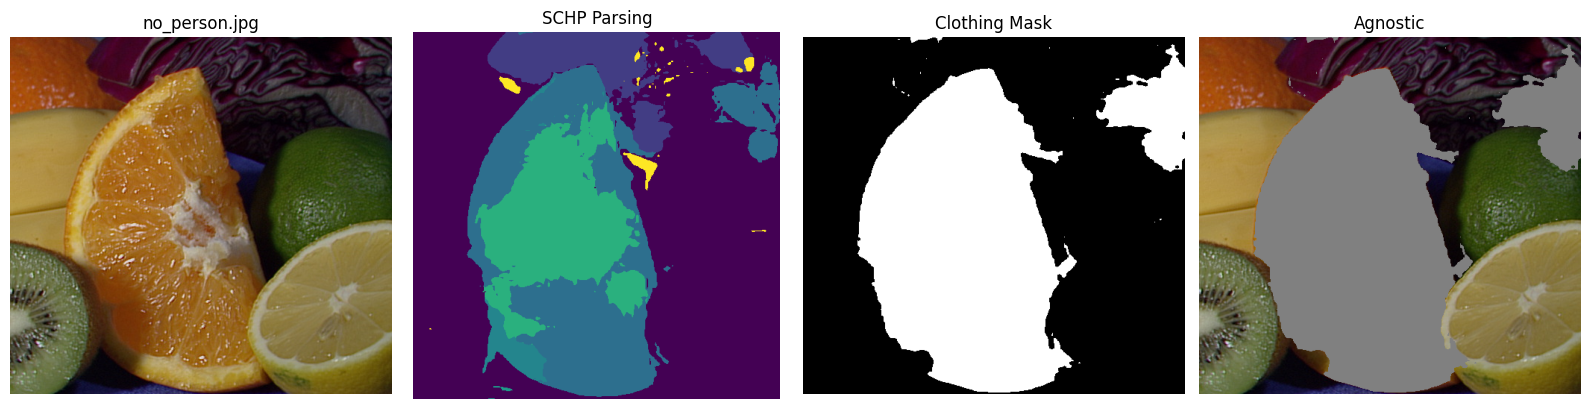

Parsing labels: [ 0  2  4  5  6  7 11]
Mask percentage: 39.22 %


In [ ]:
person_edge_tests = [
    ("person_02.png", os.path.join(PERSON_PATH, "person_02.png"),
     "Hair over shoulders"),

    ("person_03.png", os.path.join(PERSON_PATH, "person_03.png"),
     "Hair over shoulders"),

    ("person_crossed_arms.jpg",
     os.path.join(EDGE_PATH, "person_crossed_arms.jpg"),
     "Crossed arms"),

    ("no_person.jpg",
     os.path.join(EDGE_PATH, "no_person.jpg"),
     "No person")
]

print("===== Q2 PERSON EDGE-CASE TEST =====")

for name, path, case in person_edge_tests:

    print("\n" + "=" * 60)
    print("IMAGE:", name)
    print("EDGE CASE:", case)
    print("EXISTS:", os.path.exists(path))
    print("=" * 60)

    if not os.path.exists(path):
        continue

    image = Image.open(path).convert("RGB")

    # SAME SCHP pipeline
    inputs = processor(
        images=image,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.parsing_logits

    parsing_map = (
        logits.argmax(dim=1)[0]
        .detach()
        .cpu()
        .numpy()
    )

    prob = torch.softmax(
        logits,
        dim=1
    )[0].detach().cpu().numpy()

    # SAME clothing mask logic
    cloth_mask = (
        (prob[4] > 0.20) |
        (prob[7] > 0.20) |
        (prob[8] > 0.20)
    ).astype(np.uint8)

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5, 5)
    )

    cloth_mask = cv2.morphologyEx(
        cloth_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    image_np = np.array(image)

    if cloth_mask.shape != image_np.shape[:2]:
        cloth_mask = cv2.resize(
            cloth_mask,
            (image_np.shape[1], image_np.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

    agnostic = image_np.copy()

    agnostic[cloth_mask == 1] = [
        128, 128, 128
    ]

    # Display
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.title(name)
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(parsing_map)
    plt.title("SCHP Parsing")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(cloth_mask, cmap="gray")
    plt.title("Clothing Mask")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(agnostic)
    plt.title("Agnostic")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(
        "Parsing labels:",
        np.unique(parsing_map)
    )

    print(
        "Mask percentage:",
        round(
            100 * cloth_mask.sum()
            / cloth_mask.size,
            2
        ),
        "%"
    )

===== Q2 SEATED + SIDE POSE TEST =====

TESTING: person_seated.jpg
Exists: True


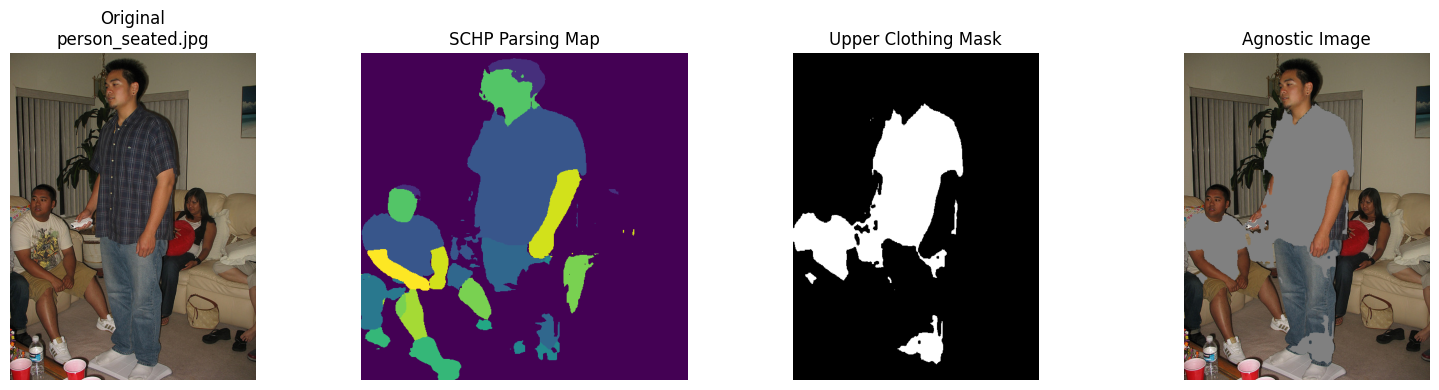

Unique parsing labels: [ 0  2  4  5  6  7  9 10 11 12 13 14 15]
Masked pixels: 51971
Mask percentage: 16.92 %

TESTING: person_side_pose.jpg
Exists: True


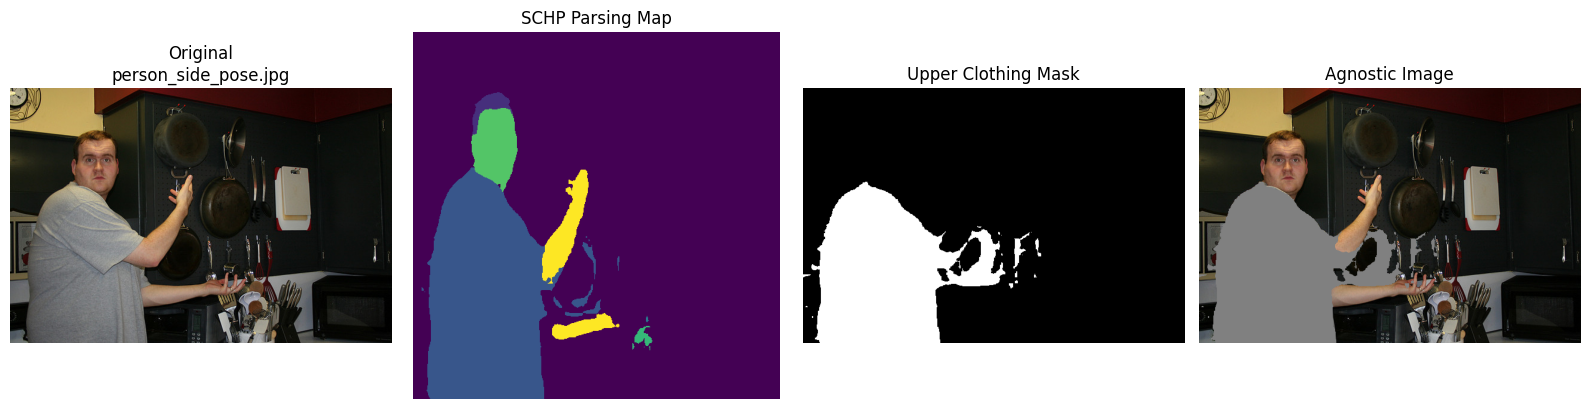

Unique parsing labels: [ 0  2  4  6 10 11 15]
Masked pixels: 51967
Mask percentage: 19.02 %

✅ SEATED + SIDE POSE TEST COMPLETED


In [ ]:
import os
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image

test_cases = [
    ("person_seated.jpg",
     os.path.join(EDGE_PATH, "person_seated.jpg")),

    ("person_side_pose.jpg",
     os.path.join(EDGE_PATH, "person_side_pose.jpg"))
]

print("===== Q2 SEATED + SIDE POSE TEST =====")

for filename, path in test_cases:

    print("\n" + "=" * 65)
    print("TESTING:", filename)
    print("Exists:", os.path.exists(path))
    print("=" * 65)

    if not os.path.exists(path):
        print("❌ File not found")
        continue

    # Load image
    image = Image.open(path).convert("RGB")

    # --------------------------------------------------
    # SCHP HUMAN PARSING
    # --------------------------------------------------
    inputs = processor(
        images=image,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.parsing_logits

    parsing_map = (
        logits.argmax(dim=1)[0]
        .detach()
        .cpu()
        .numpy()
    )

    # --------------------------------------------------
    # PROBABILITY MAP
    # --------------------------------------------------
    prob = torch.softmax(
        logits,
        dim=1
    )[0].detach().cpu().numpy()

    # SAME clothing-mask logic used in Q2
    cloth_mask = (
        (prob[4] > 0.20) |
        (prob[7] > 0.20) |
        (prob[8] > 0.20)
    ).astype(np.uint8)

    # --------------------------------------------------
    # MORPHOLOGY
    # --------------------------------------------------
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5, 5)
    )

    cloth_mask = cv2.morphologyEx(
        cloth_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # --------------------------------------------------
    # CREATE AGNOSTIC IMAGE
    # --------------------------------------------------
    image_np = np.array(image)

    if cloth_mask.shape != image_np.shape[:2]:
        cloth_mask = cv2.resize(
            cloth_mask,
            (image_np.shape[1], image_np.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

    agnostic = image_np.copy()

    agnostic[cloth_mask == 1] = [
        128,
        128,
        128
    ]

    # --------------------------------------------------
    # DISPLAY RESULTS
    # --------------------------------------------------
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.title(f"Original\n{filename}")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(parsing_map)
    plt.title("SCHP Parsing Map")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(cloth_mask, cmap="gray")
    plt.title("Upper Clothing Mask")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(agnostic)
    plt.title("Agnostic Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # DIAGNOSTIC INFORMATION
    # --------------------------------------------------
    print(
        "Unique parsing labels:",
        np.unique(parsing_map)
    )

    print(
        "Masked pixels:",
        int(cloth_mask.sum())
    )

    print(
        "Mask percentage:",
        round(
            100 * cloth_mask.sum()
            / cloth_mask.size,
            2
        ),
        "%"
    )

print("\n✅ SEATED + SIDE POSE TEST COMPLETED")